# KPI-oriented Analysis
This notebook processes cargo pickup data to conduct turnaround and weighbridge utilisation analysis.

In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_DIR = 'figures'
DATA_DIR = 'data'
DB_PATH = os.path.join(DATA_DIR, 'CargoPickup_IoT.sqlite')

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. Load Data

In [2]:
success_pickups = pd.read_csv(os.path.join(DATA_DIR, 'success_pickups.csv'), low_memory=False)
success_pickups['timestamp'] = pd.to_datetime(success_pickups['timestamp'])

gps_processed = pd.read_csv(os.path.join(DATA_DIR, 'gps_processed.csv'), low_memory=False)
pickup_mapping = success_pickups[['Truck ID', 'Pickup Plan ID', 'pickup']].drop_duplicates()
df_gps_merged = gps_processed.merge(pickup_mapping, on=['Truck ID', 'Pickup Plan ID'], how='left')

conn = sqlite3.connect(DB_PATH)
o2IoTo_df = pd.read_sql_query("SELECT * FROM object_IoTobject", conn)
conn.close()

## 2. Classify Pickups and Analyse Durations

In [3]:
enter_success_df = success_pickups[success_pickups['activity'] == 'Enter the port'].copy()
enter_success_df['hour_of_day'] = enter_success_df['timestamp'].dt.hour
enter_success_df = enter_success_df[['pickup', 'timestamp', 'hour_of_day', 'rain_condition']]
enter_success_df = enter_success_df.rename(columns={'timestamp': 'entry_time'})

success_pickup_duration_df = success_pickups.groupby('pickup').agg(
    start_time=('timestamp', 'min'),
    end_time=('timestamp', 'max')
).reset_index()

success_pickup_duration_df['duration_hours'] = (
    (success_pickup_duration_df['end_time'] - success_pickup_duration_df['start_time'])
    .dt.total_seconds() / 3600
)

df_success_pickup_analysis = pd.merge(enter_success_df, success_pickup_duration_df, on='pickup', how='inner')
df_success_pickup_analysis = df_success_pickup_analysis[['pickup', 'hour_of_day', 'duration_hours', 'rain_condition']]

success_q3 = df_success_pickup_analysis['duration_hours'].quantile(0.75)
success_pickup_short = df_success_pickup_analysis[df_success_pickup_analysis['duration_hours'] <= success_q3]['pickup']
success_pickup_long = df_success_pickup_analysis[df_success_pickup_analysis['duration_hours'] > success_q3]['pickup']

## 3. Distribution of Successful Pickups

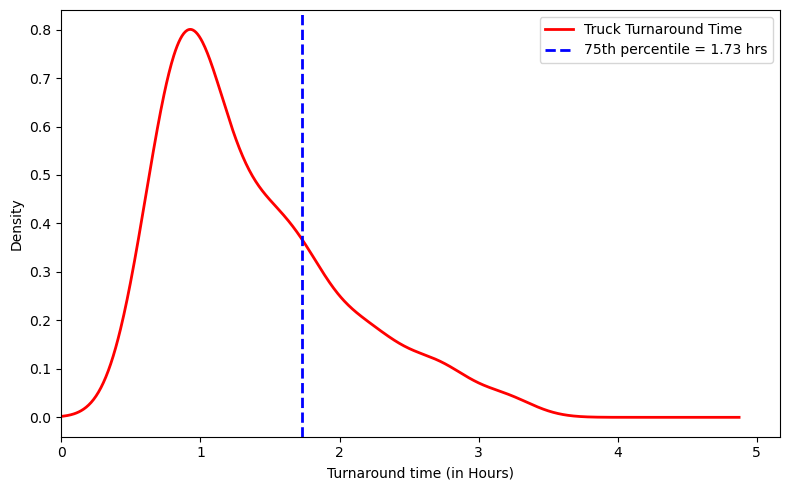

In [4]:
plt.figure(figsize=(8, 5))
p75_success = df_success_pickup_analysis['duration_hours'].quantile(0.75)
df_success_pickup_analysis['duration_hours'].plot(kind='kde', color='red', linewidth=2, label='Truck Turnaround Time')

plt.axvline(p75_success, color='blue', linestyle='--', linewidth=2, label=f'75th percentile = {p75_success:.2f} hrs')

plt.xlabel('Turnaround time (in Hours)')
plt.ylabel('Density')
plt.xlim(left=0)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'Distribution_Successful_Pickups.png'), dpi=300)
plt.show()

## 4. Normal vs Long Path Duration

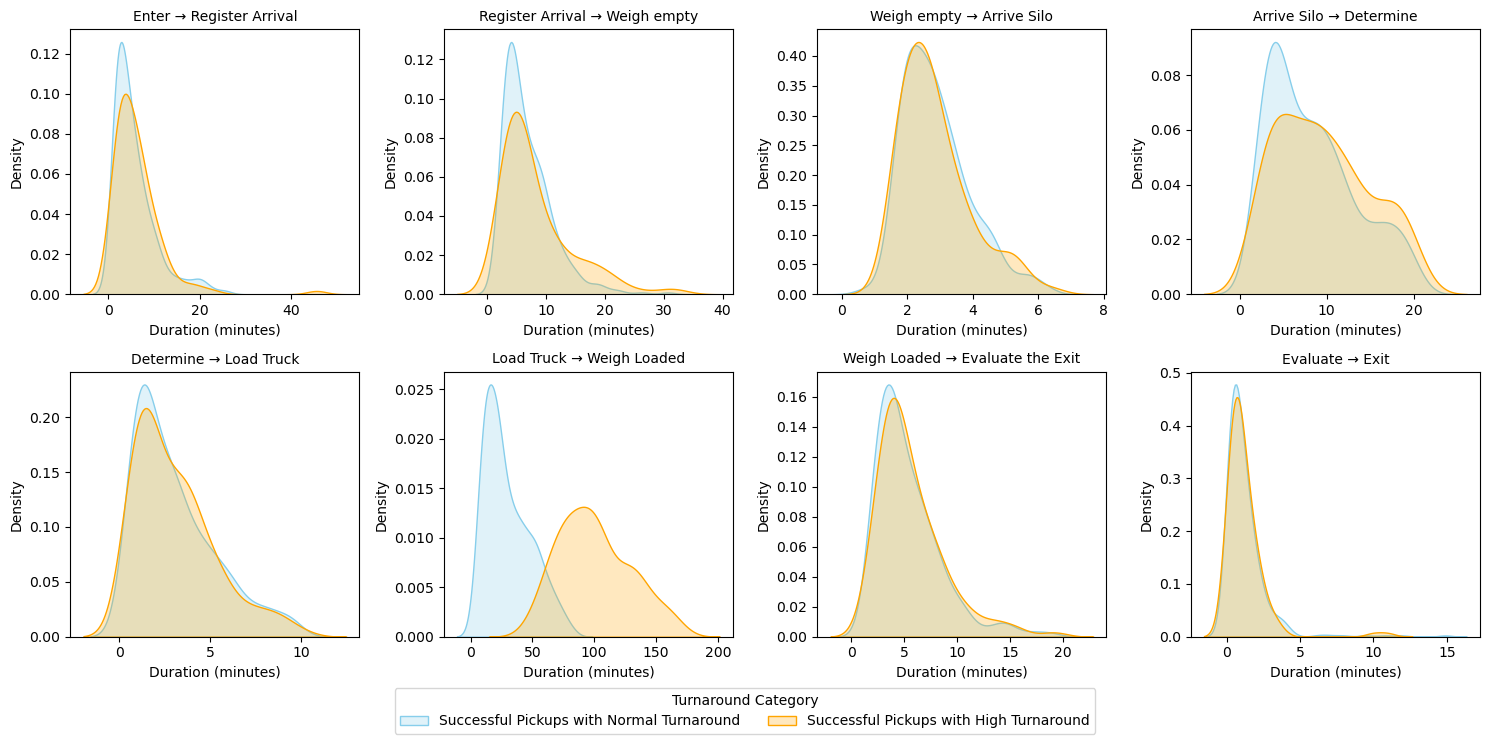

In [5]:
# Prepare path durations
cols = ['Enter_RegisterArrival','Register_EmptyWeighing','EmptyWeighing_ArrivalSilo', 'ArrivalSilo_Determine','Determine_Stack', 'Stack_Loaded','LoadedWeighing_Eval','Eval_Exit']
def first_valid(s):
    s = pd.to_numeric(s, errors='coerce').dropna()
    return s.iloc[0] if len(s) else np.nan
per_pickup = success_pickups.groupby('pickup').agg({c: first_valid for c in cols})

per_pickup['Turnaround_Category'] = None
per_pickup.loc[per_pickup.index.isin(success_pickup_short), 'Turnaround_Category'] = 'Normal'
per_pickup.loc[per_pickup.index.isin(success_pickup_long),  'Turnaround_Category'] = 'High'

# Plot Normal_Long_Path_Duration
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.ravel()

duration_cols_map = {
    'Enter_RegisterArrival': 'Enter → Register Arrival',
    'Register_EmptyWeighing': 'Register Arrival → Weigh empty',
    'EmptyWeighing_ArrivalSilo': 'Weigh empty → Arrive Silo',
    'ArrivalSilo_Determine': 'Arrive Silo → Determine',
    'Determine_Stack': 'Determine → Load Truck',
    'Stack_Loaded': 'Load Truck → Weigh Loaded',
    'LoadedWeighing_Eval': 'Weigh Loaded → Evaluate the Exit',
    'Eval_Exit': 'Evaluate → Exit'
}

for i, (col, title) in enumerate(duration_cols_map.items()):
    normal_data = pd.to_numeric(per_pickup.loc[per_pickup['Turnaround_Category'] == 'Normal', col], errors='coerce').dropna()
    long_data = pd.to_numeric(per_pickup.loc[per_pickup['Turnaround_Category'] == 'High', col], errors='coerce').dropna()

    def plot_or_line(data, ax, color, label):
        if data.empty: return
        if data.nunique() <= 1:
            ax.axvline(data.iloc[0], color=color, linestyle='-', linewidth=2, label=label)
        else:
            sns.kdeplot(data, ax=ax, label=label, fill=True, common_norm=False, color=color)

    plot_or_line(normal_data, axes[i], 'skyblue', 'Successful Pickups with Normal Turnaround')
    plot_or_line(long_data, axes[i], 'orange', 'Successful Pickups with High Turnaround')

    axes[i].set_title(title, fontsize=10)
    axes[i].set_xlabel("Duration (minutes)")
    axes[i].set_ylabel("Density")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, title="Turnaround Category")

plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig(os.path.join(OUTPUT_DIR, 'Normal_Long_Path_Duration.png'), dpi=300, bbox_inches='tight')
plt.show()

## 5. Normal vs Long Unauthorised Distribution

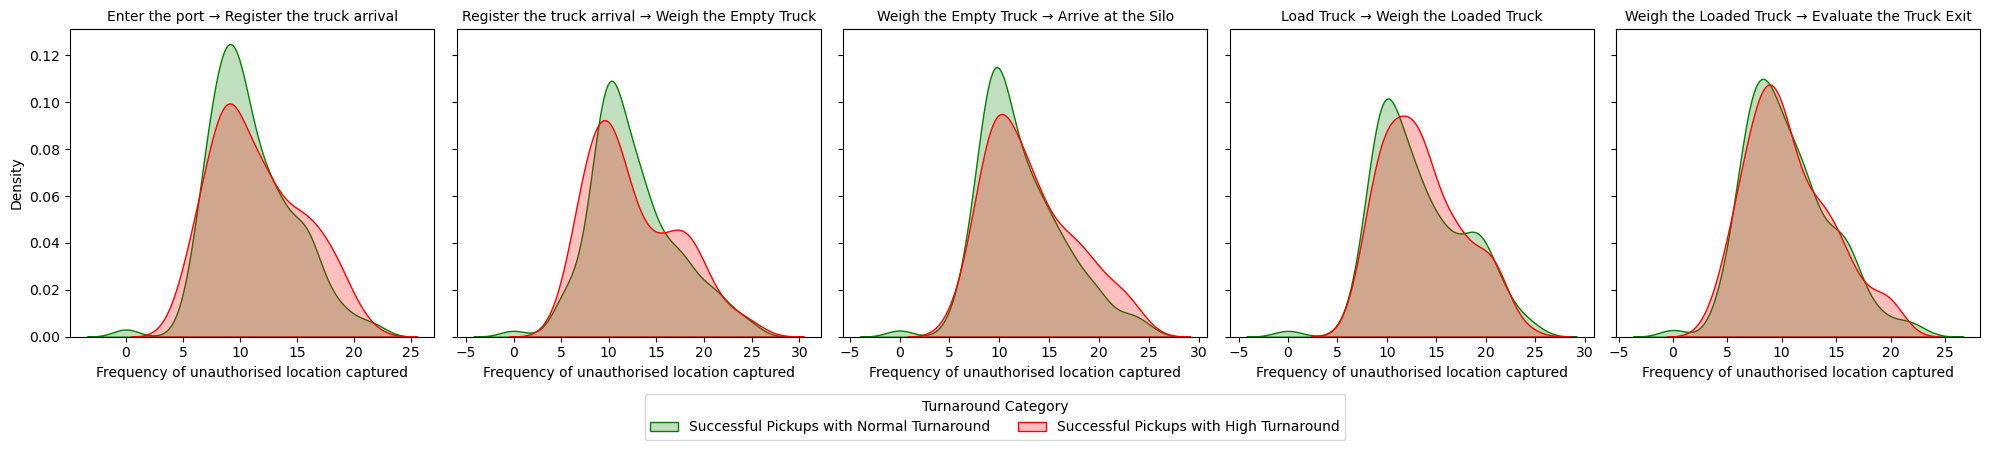

In [6]:
# Prepare unauthorised location counts
cols_gps = ['Enter_to_Register_TTL_count','Register_to_WeighEmpty_TTL_count', 'WeighEmpty_to_ArriveSilo_TTL_count','Stack_Loaded_TTL_count', 'WeighLoaded_to_Exit_TTL_count']
per_pickup_gps = success_pickups.groupby('pickup').agg({c: first_valid for c in cols_gps})

per_pickup_gps['Turnaround_Category'] = None
per_pickup_gps.loc[per_pickup_gps.index.isin(success_pickup_short), 'Turnaround_Category'] = 'Normal'
per_pickup_gps.loc[per_pickup_gps.index.isin(success_pickup_long),  'Turnaround_Category'] = 'High'

# Plot Normal_Long_Unauthorised_Distribution
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

ttl_cols_map = {
    'Enter_to_Register_TTL_count': 'Enter the port → Register the truck arrival',
    'Register_to_WeighEmpty_TTL_count': 'Register the truck arrival → Weigh the Empty Truck',
    'WeighEmpty_to_ArriveSilo_TTL_count': 'Weigh the Empty Truck → Arrive at the Silo',
    'Stack_Loaded_TTL_count': 'Load Truck → Weigh the Loaded Truck',
    'WeighLoaded_to_Exit_TTL_count': 'Weigh the Loaded Truck → Evaluate the Truck Exit'
}

for i, (col, title) in enumerate(ttl_cols_map.items()):
    normal_data = pd.to_numeric(per_pickup_gps.loc[per_pickup_gps['Turnaround_Category'] == 'Normal', col], errors='coerce').dropna()
    high_data = pd.to_numeric(per_pickup_gps.loc[per_pickup_gps['Turnaround_Category'] == 'High', col], errors='coerce').dropna()

    def plot_or_line(data, ax, color, label):
        if data.empty: return
        if data.nunique() <= 1:
            ax.axvline(data.iloc[0], color=color, linestyle='-', linewidth=2, label=label)
        else:
            sns.kdeplot(data, ax=ax, label=label, fill=True, common_norm=False, color=color)

    plot_or_line(normal_data, axes[i], 'green', 'Successful Pickups with Normal Turnaround')
    plot_or_line(high_data, axes[i], 'red', 'Successful Pickups with High Turnaround')

    axes[i].set_title(title, fontsize=10)
    axes[i].set_xlabel("Frequency of unauthorised location captured")
    axes[i].set_ylabel("Density")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, title="Turnaround Category")

plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig(os.path.join(OUTPUT_DIR, 'Normal_Long_Unauthorised_Distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

## 6. Detour Ratio for All Paths

In [7]:
df_gps_merged['Turnaround_Category'] = None
df_gps_merged.loc[df_gps_merged['pickup'].isin(success_pickup_short), 'Turnaround_Category'] = 'Normal'
df_gps_merged.loc[df_gps_merged['pickup'].isin(success_pickup_long),  'Turnaround_Category'] = 'High'

def haversine_np(lat1, lon1, lat2, lon2):
    R = 6_371_000.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

# Compute detour metrics
sp = df_gps_merged.copy()
sp = sp.dropna(subset=['Latitude','Longitude','Timestamp','Truck ID','pickup','Path_Stage']).copy()
sp['Timestamp'] = pd.to_datetime(sp['Timestamp'])
sp = sp.sort_values(['Truck ID','pickup','Timestamp'])
sp['seg_id'] = sp.groupby(['Truck ID','pickup'])['Path_Stage'].transform(lambda s: s.ne(s.shift()).cumsum())

def detour_metrics(g):
    g = g[['Latitude','Longitude','Timestamp']].copy()
    g[['lat_prev','lon_prev','ts_prev']] = g.shift(1)
    g = g.dropna()
    if g.empty:
        return pd.Series({'n_points':1,'path_len_m':0.0,'d_straight_m':0.0,'detour_excess_m':0.0,'detour_ratio':np.nan})

    step = haversine_np(g['lat_prev'], g['lon_prev'], g['Latitude'], g['Longitude'])
    path_len = step.sum()
    lat0, lon0 = g.iloc[0][['Latitude','Longitude']]
    lat1, lon1 = g.iloc[-1][['Latitude','Longitude']]
    d_straight = float(haversine_np(lat0, lon0, lat1, lon1))

    detour_excess = max(0.0, path_len - d_straight)
    detour_ratio  = (detour_excess / d_straight) if d_straight > 0 else np.nan
    return pd.Series({'n_points': len(g)+1, 'path_len_m': path_len, 'd_straight_m': d_straight, 'detour_excess_m': detour_excess, 'detour_ratio': detour_ratio})

detour_all = sp.groupby(['Truck ID','pickup','Path_Stage','seg_id'], as_index=False).apply(detour_metrics).reset_index(drop=True)
cats = sp[['Truck ID','pickup','Turnaround_Category']].drop_duplicates()
detour_all = detour_all.merge(cats, on=['Truck ID','pickup'], how='left')
detour_all

/var/folders/_8/t9lzz28d1nx60l3whmwkckv00000gn/T/ipykernel_4808/2547544265.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  detour_all = sp.groupby(['Truck ID','pickup','Path_Stage','seg_id'], as_index=False).apply(detour_metrics).reset_index(drop=True)


,Truck ID,pickup,Path_Stage,seg_id,n_points,path_len_m,d_straight_m,detour_excess_m,detour_ratio,Turnaround_Category
0,tr1,1.0,entry_to_register,1,24.0,1046.161730,896.899149,149.262581,0.166421,High
1,tr1,1.0,register_to_weigh,2,27.0,2820.559872,2461.664149,358.895723,0.145794,High
2,tr1,1.0,weigh_to_exit,5,26.0,853.153219,671.111703,182.041516,0.271254,High
3,tr1,1.0,weigh_to_yard,3,20.0,2257.953364,1981.801749,276.151615,0.139344,High
4,tr1,1.0,yard_to_weigh,4,12.0,2423.949884,1958.731536,465.218348,0.237510,High
...,...,...,...,...,...,...,...,...,...,...
2295,tr9,489.0,entry_to_register,1,18.0,1037.060082,862.336653,174.723429,0.202616,Normal
2296,tr9,489.0,register_to_weigh,2,28.0,2740.394809,2470.830368,269.564442,0.109099,Normal
2297,tr9,489.0,weigh_to_exit,5,13.0,755.968285,609.614218,146.354067,0.240077,Normal
2298,tr9,489.0,weigh_to_yard,3,20.0,2241.699933,1973.798553,267.901379,0.135729,Normal


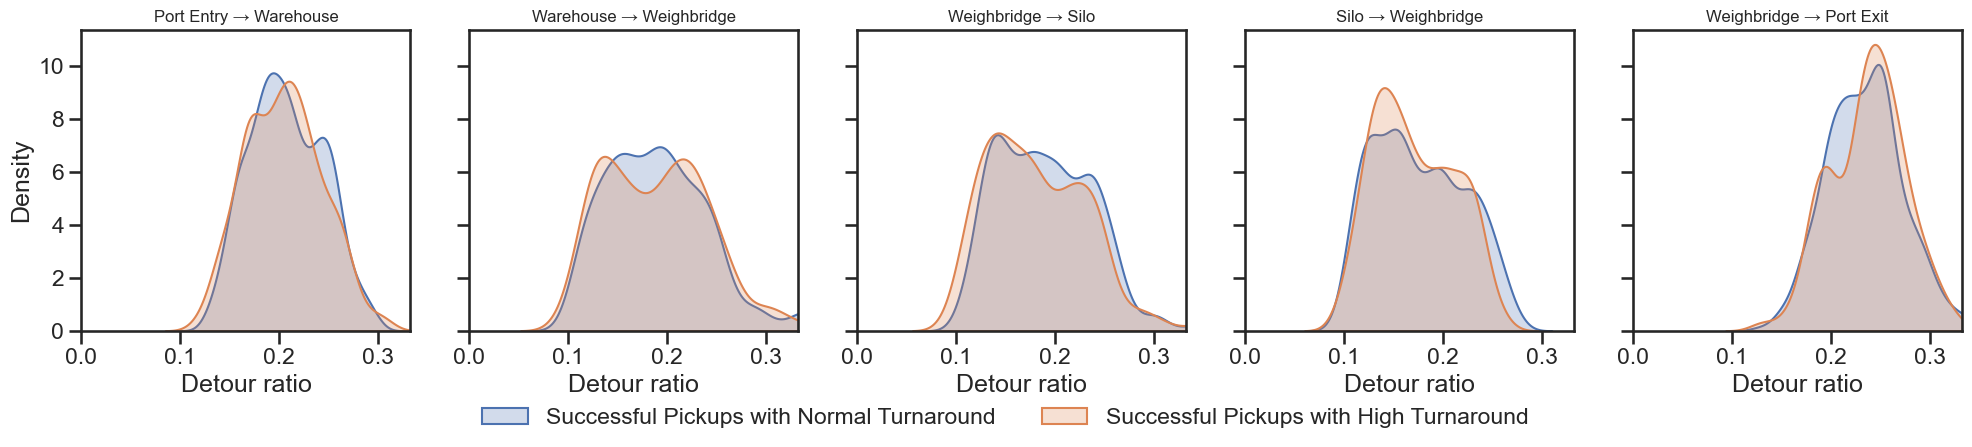

In [8]:
# Plot detour_ratio_all_paths
sns.set_theme(style='ticks', context='talk')

d = detour_all.dropna(subset=['detour_ratio']).copy()
d['detour_ratio'] = d['detour_ratio'].clip(lower=0)

xmax = float(d['detour_ratio'].quantile(0.99))
if not np.isfinite(xmax) or xmax <= 0: xmax = float(d['detour_ratio'].max())

label_map = {
    'High': 'Successful Pickups with High Turnaround',
    'Normal': 'Successful Pickups with Normal Turnaround'
}

title_map = {
    'entry_to_register': 'Port Entry → Warehouse',
    'register_to_weigh': 'Warehouse → Weighbridge',
    'weigh_to_exit': 'Weighbridge → Port Exit',
    'weigh_to_yard': 'Weighbridge → Silo',
    'yard_to_weigh': 'Silo → Weighbridge'
}

stages_order = ['entry_to_register','register_to_weigh','weigh_to_yard','yard_to_weigh','weigh_to_exit']
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=True, sharey=True)
axes = axes.ravel()
plt.tight_layout()

legend_once = set()
for ax, stage in zip(axes, stages_order):
    sub = d[d['Path_Stage'] == stage]
    if sub.empty:
        ax.set_title(title_map.get(stage, stage), fontsize=12)
        ax.set_xlim(0, xmax)
        ax.set_yticks([])
        continue

    for cat in ['Normal','High']: 
        sub_cat = sub[sub['Turnaround_Category'] == cat]
        if sub_cat.empty: continue
        lbl = label_map.get(cat, cat) if cat not in legend_once else '_nolegend_'
        sns.kdeplot(data=sub_cat, x='detour_ratio', fill=True, alpha=0.25, bw_adjust=0.8, clip=(0, xmax), common_norm=False, warn_singular=False, ax=ax, label=lbl)
        legend_once.add(cat)

    ax.set_title(title_map.get(stage, stage), fontsize=12)
    ax.set_xlim(0, xmax)
    ax.set_xlabel('Detour ratio')
    ax.set_ylabel('Density')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=len(labels), frameon=False)
plt.savefig(os.path.join(OUTPUT_DIR, 'detour_ratio_all_paths.png'), dpi=300, bbox_inches='tight')
plt.show()
sns.reset_defaults()

## 7. Weighbridge Utilisation

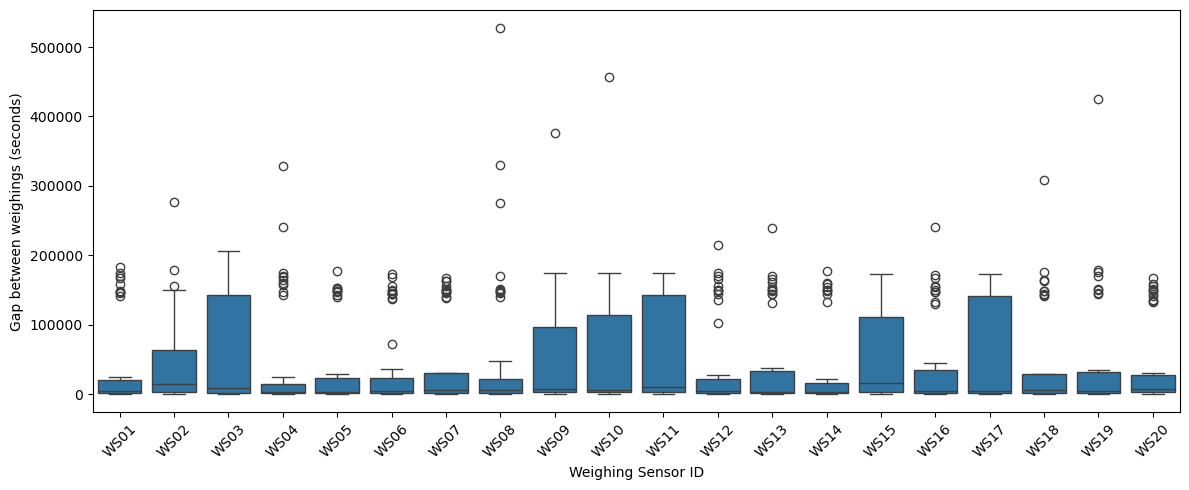

In [9]:
# Prepare weighbridge data
weigh_df = o2IoTo_df[o2IoTo_df['ocel_qualifier'].isin([
    'Weight sensor measuring loaded truck weight',
    'Weight sensor measuring empty truck weight'
])].copy()
weigh_df = weigh_df.rename(columns={
    'ocel_IoTobject_id': 'IoT_Object_ID',
    'ocel_object_id': 'Truck ID',
    'ocel_time': 'timestamp',
})
weigh_df['timestamp'] = pd.to_datetime(weigh_df['timestamp'])

weighing_pickups = pd.merge(success_pickups, weigh_df, on=['Truck ID', 'timestamp'])
weighing_pickups['Turnaround Category'] = None
weighing_pickups.loc[weighing_pickups['pickup'].isin(success_pickup_short), 'Turnaround Category'] = 'Normal'
weighing_pickups.loc[weighing_pickups['pickup'].isin(success_pickup_long), 'Turnaround Category'] = 'High'
weighing_pickups_filtered = weighing_pickups[['Turnaround Category','activity','IoT_Object_ID','timestamp']]

# Plot weighbridge_utilisation
weigh_all = weighing_pickups_filtered.sort_values(['IoT_Object_ID', 'timestamp'])
weigh_all['gap_sec'] = weigh_all.groupby('IoT_Object_ID')['timestamp'].diff().dt.total_seconds()

weigh_all = weigh_all.dropna(subset=['gap_sec'])
weigh_all = weigh_all[weigh_all['gap_sec'] >= 0]

plt.figure(figsize=(12,5))
sns.boxplot(data=weigh_all, x='IoT_Object_ID', y='gap_sec')
plt.ylabel('Gap between weighings (seconds)')
plt.xlabel('Weighing Sensor ID')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'weighbridge_utilisation.png'), dpi=300)
plt.show()